torch.Size([2, 16, 64])


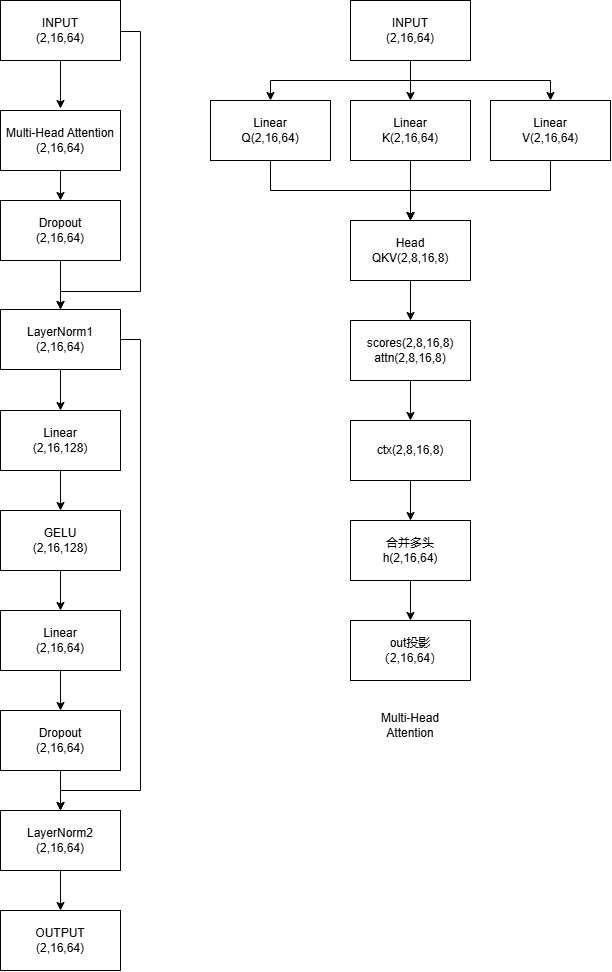

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class MultiHeadAttention(nn.Module):
    def __init__(self,d_model=64,n_heads=8,ffn=128,dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model,self.n_heads,self.d_head = d_model,n_heads,d_model // n_heads
        self.q = nn.Linear(d_model,d_model)
        self.k = nn.Linear(d_model,d_model)
        self.v = nn.Linear(d_model,d_model)
        self.out = nn.Linear(d_model,d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model,ffn),nn.GELU(),
            nn.Linear(ffn,d_model),
        )
        self.drop = nn.Dropout(dropout)
    def forward(self,x,mask=None):
        B,T,D = x.shape
        Q = self.q(x).reshape(B,T,self.n_heads,self.d_head).permute(0,2,1,3)
        K = self.k(x).reshape(B,T,self.n_heads,self.d_head).permute(0,2,1,3)
        V = self.v(x).reshape(B,T,self.n_heads,self.d_head).permute(0,2,1,3)
        scores = torch.matmul(Q,K.transpose(-2,-1)) / (self.d_head ** 0.5)
        if mask is not None:
            scores = scores.mask_fill(mask == 0,float('-inf'))
        attn = self.drop(F.softmax(scores,dim=-1))
        ctx = torch.matmul(attn,V)
        h = ctx.permute(0,2,1,3).reshape(B,T,D)
        h = self.out(h)
        x = self.ln1(x + self.drop(h))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x
model = MultiHeadAttention()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,16,64))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('MHA+FFN.png')
display.display(img) 

torch.Size([2, 32, 32, 32])


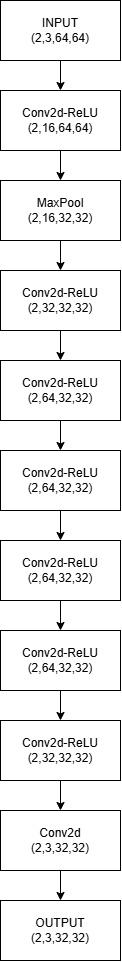

In [32]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F
class CascadingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3,16,5,padding=2),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU(),
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),nn.ReLU(),
        )
        self.stage3 = nn.Sequential(
            nn.Conv2d(64,32,3,padding=1),nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),nn.ReLU(),
        )
        self.head = nn.Conv2d(32,3,1)
    def forward(self,x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return x

model = CascadingNet()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,3,64,64))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('CascadingNet.png')
display.display(img) 